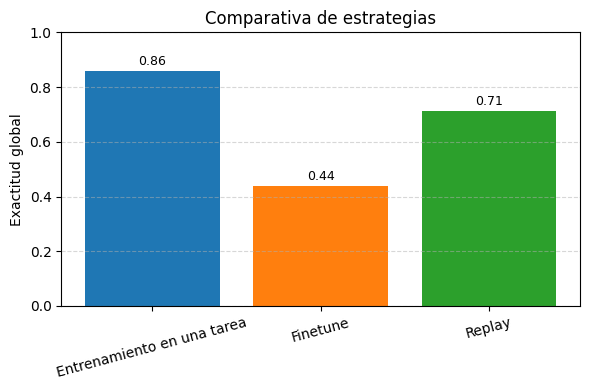

In [1]:
#!/usr/bin/env python3
# visualizar_global.py – Comparativa de valores "global" con etiquetas personalizadas

import json
import matplotlib.pyplot as plt
from pathlib import Path

# Leer archivo JSON
metrics = json.loads(Path("comparativa_global.json").read_text())

# Filtrar solo las métricas globales
global_metrics = [m for m in metrics if m["task"] == "global"]

# Extraer valores de exactitud
accuracies = [m["accuracy"] for m in global_metrics]

# ✅ Personaliza tus etiquetas aquí (una por cada valor global)
labels = ["Entrenamiento en una tarea", "Finetune", "Replay"]  # <-- AJUSTA según tu experimento

# Validación opcional
if len(labels) != len(accuracies):
    raise ValueError("El número de etiquetas no coincide con los valores globales.")

# Colores distintos por barra (usa tab10 de matplotlib)
colors = plt.get_cmap("tab10").colors
bar_colors = colors[:len(accuracies)]

# Crear gráfico
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, accuracies, color=bar_colors)

# Mostrar valores encima de las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{acc:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1)
plt.ylabel("Exactitud global")
plt.title("Comparativa de estrategias")
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
